# 🏠 House Prices
**Kaggle: House Prices Advanced Regression**

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

## 2. Load Data

In [2]:
train = pd.read_csv('A:/FCAI level3/ML/ml_project/project/train.csv')
test  = pd.read_csv('A:/FCAI level3/ML/ml_project/project/test.csv')

print(f'Train: {train.shape}   |   Test: {test.shape}')
train.head(3)

Train: (1460, 81)   |   Test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


## 3. EDA 

### Basic Info

In [3]:
# Data types count
train.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [4]:
# Statistical summary for numerical columns
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


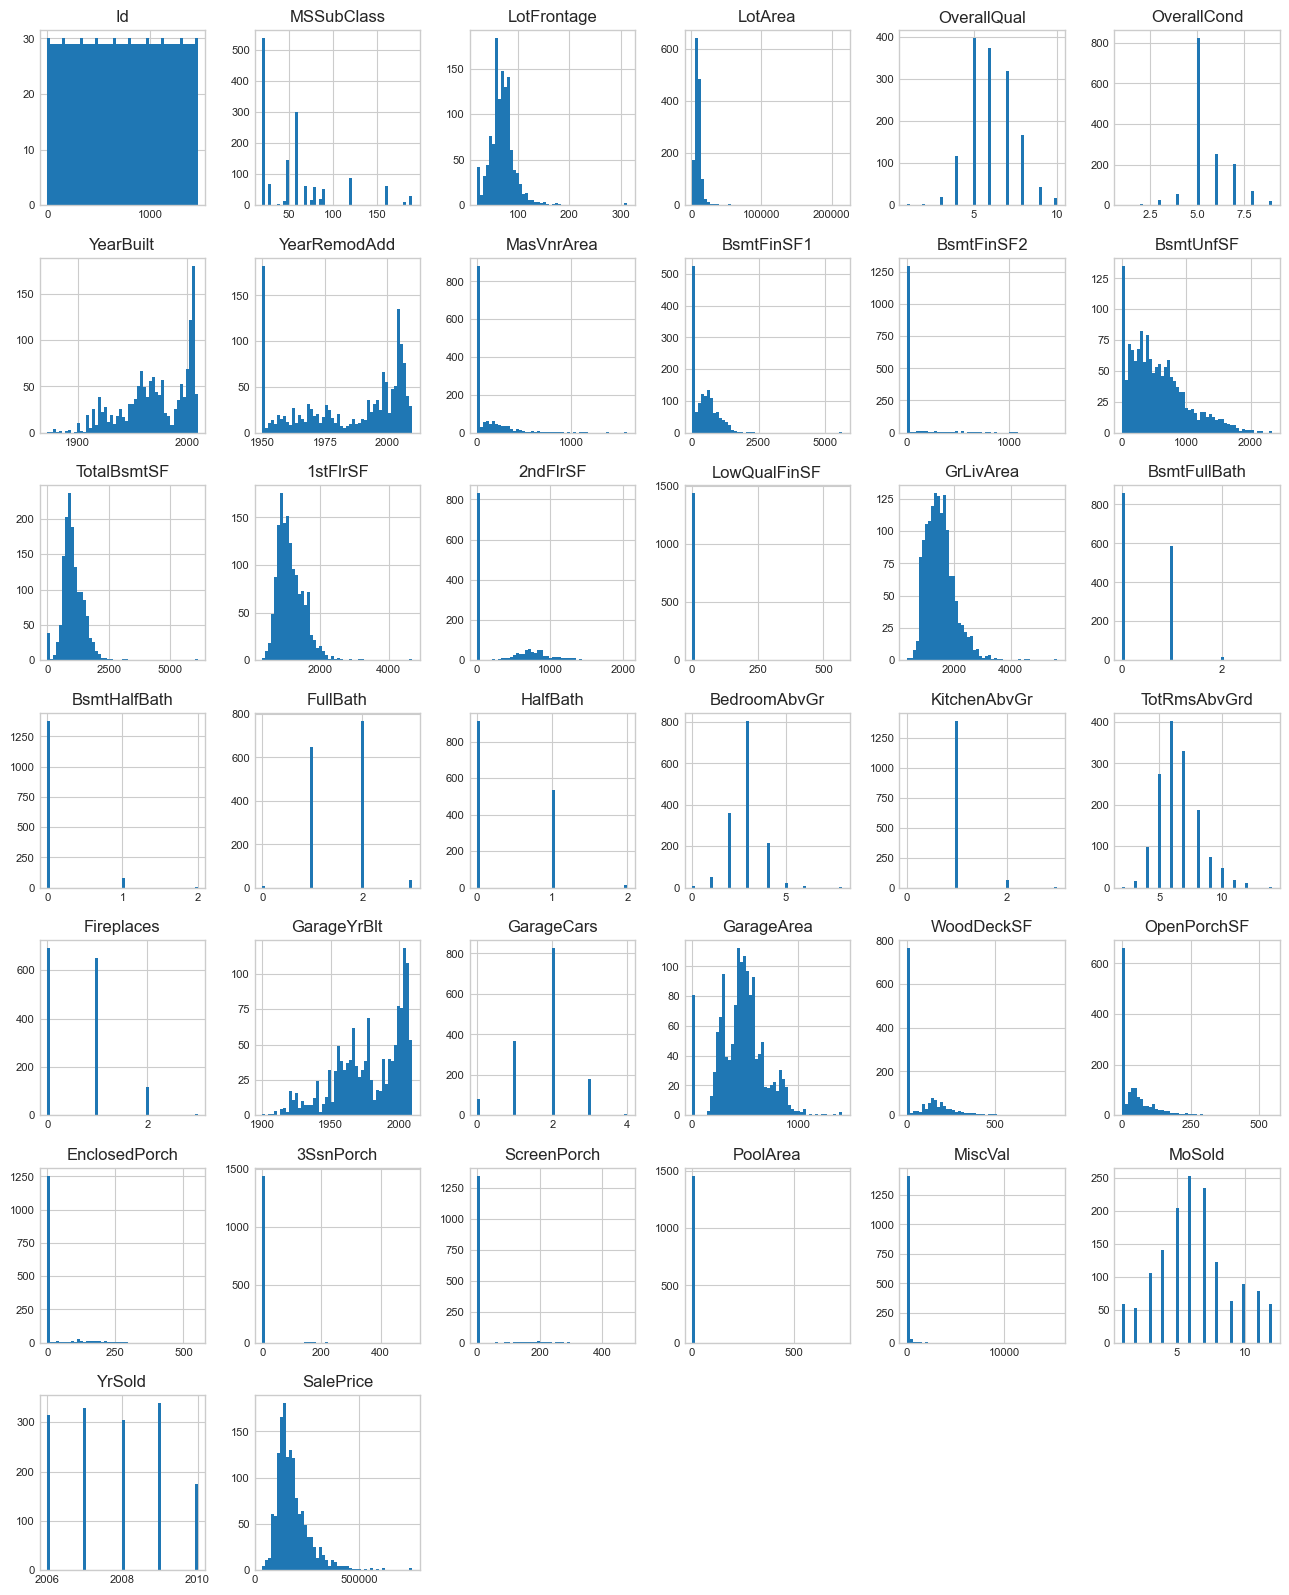

In [5]:
train.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

### Target Variable (SalePrice)

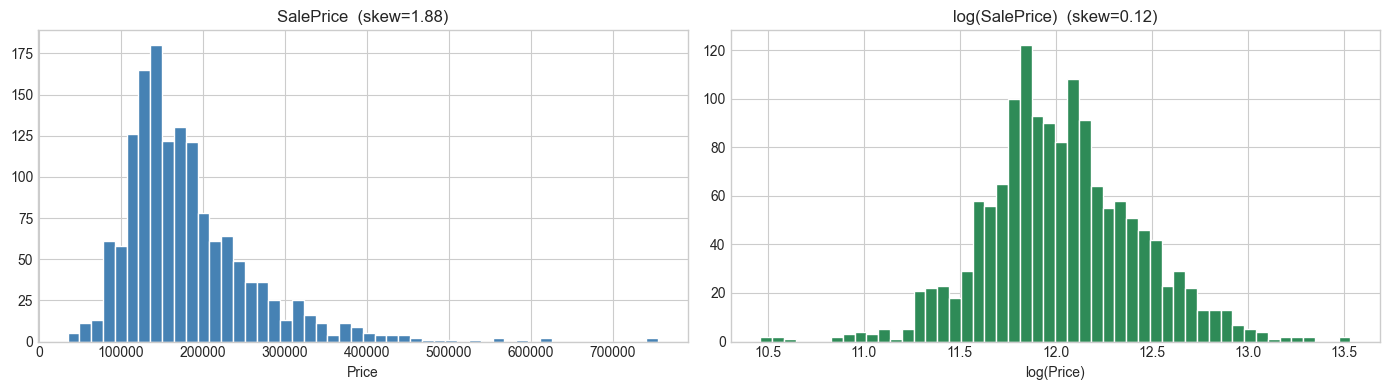

In [6]:
# Distribution of SalePrice vs Log(SalePrice)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'SalePrice  (skew={train["SalePrice"].skew():.2f})')
axes[0].set_xlabel('Price')

log_price = np.log1p(train['SalePrice'])
axes[1].hist(log_price, bins=50, color='seagreen', edgecolor='white')
axes[1].set_title(f'log(SalePrice)  (skew={log_price.skew():.2f})')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

### Missing Values

In [7]:
# Missing values in train
missing = train.isnull().sum()
missing.sum()

7829

In [8]:
missing = missing[missing > 0].sort_values(ascending=False)
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [9]:
missing_pct = (missing / len(train) * 100).round(1)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


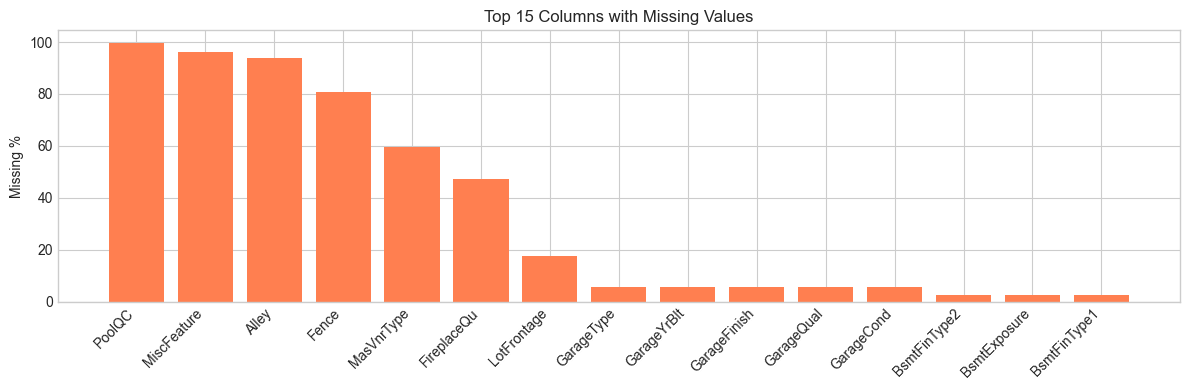

In [10]:
# Visualize top missing columns
plt.figure(figsize=(12, 4))
plt.bar(missing.index[:15], missing_pct.iloc[:15].values, color='coral')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing %')
plt.title('Top 15 Columns with Missing Values')
plt.tight_layout()
plt.show()

### Correlation with SalePrice

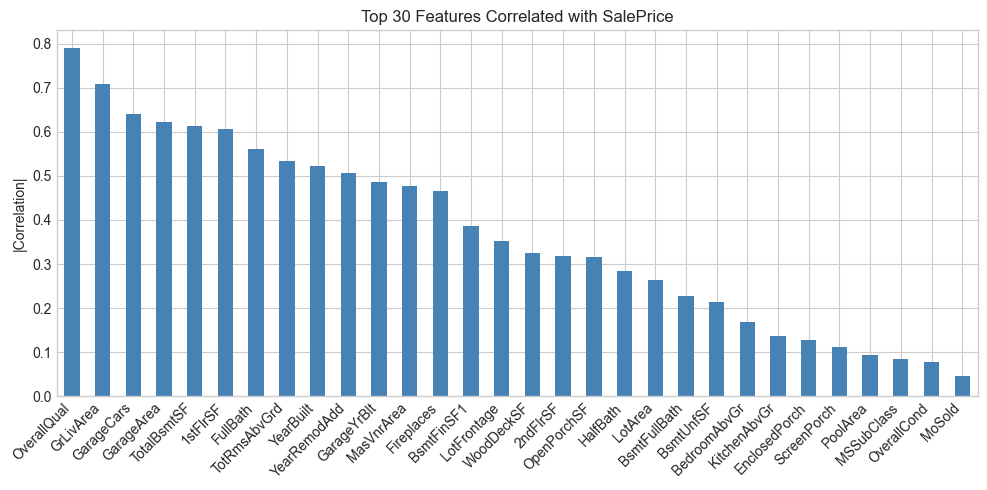

Top 5 features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']


In [11]:
# Top 30 numerical features correlated with SalePrice
num_cols = train.select_dtypes(include=[np.number]).columns.drop('Id')
corr = train[num_cols].corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
corr.head(30).plot(kind='bar', color='steelblue')
plt.title('Top 30 Features Correlated with SalePrice')
plt.ylabel('|Correlation|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('Top 5 features:', corr.head(5).index.tolist())

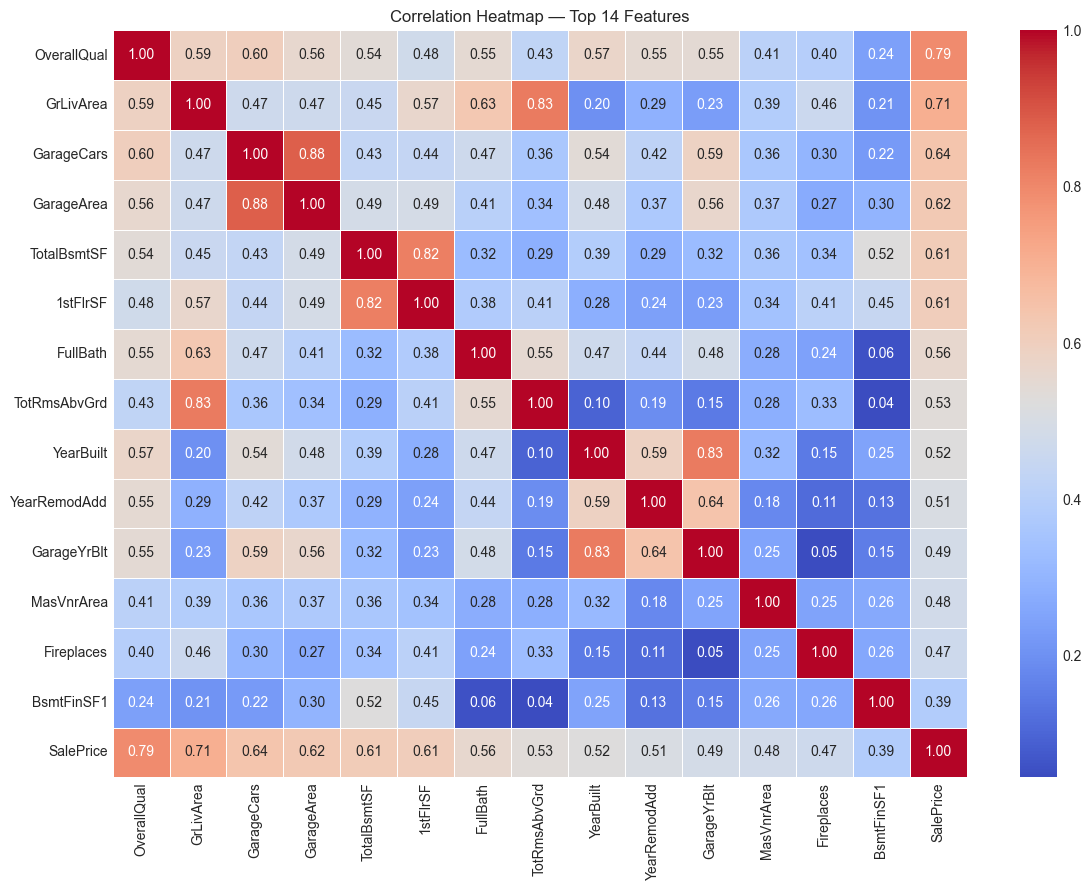

In [12]:
# Correlation heatmap for top 14 features
top_features = corr.head(14).index.tolist() + ['SalePrice']

plt.figure(figsize=(12, 9))
sns.heatmap(train[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Top 14 Features')
plt.tight_layout()
plt.show()

### Key Features vs SalePrice

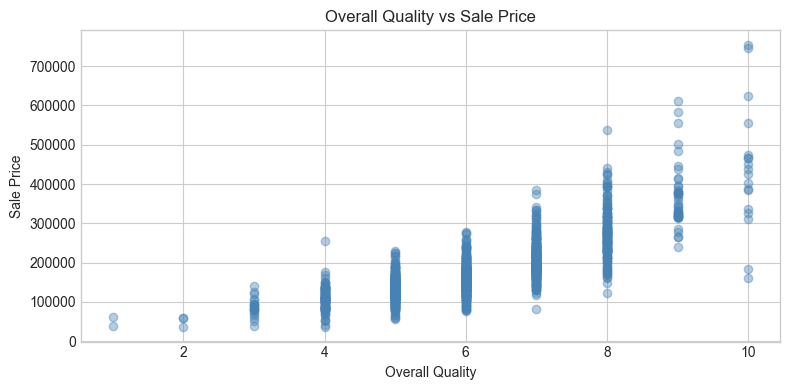

In [13]:
# Scatter: OverallQual vs SalePrice
plt.figure(figsize=(8, 4))
plt.scatter(train['OverallQual'], train['SalePrice'], alpha=0.4, color='steelblue')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price')
plt.title('Overall Quality vs Sale Price')
plt.tight_layout()
plt.show()

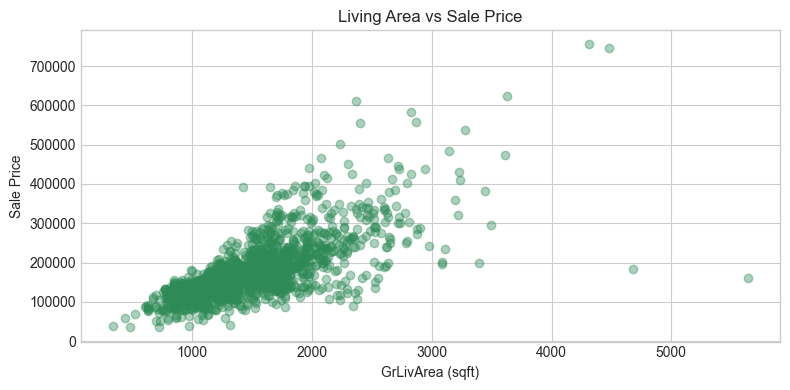

In [14]:
# Scatter: GrLivArea vs SalePrice (spot outliers)
plt.figure(figsize=(8, 4))
plt.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, color='seagreen')
plt.xlabel('GrLivArea (sqft)')
plt.ylabel('Sale Price')
plt.title('Living Area vs Sale Price')
plt.tight_layout()
plt.show()

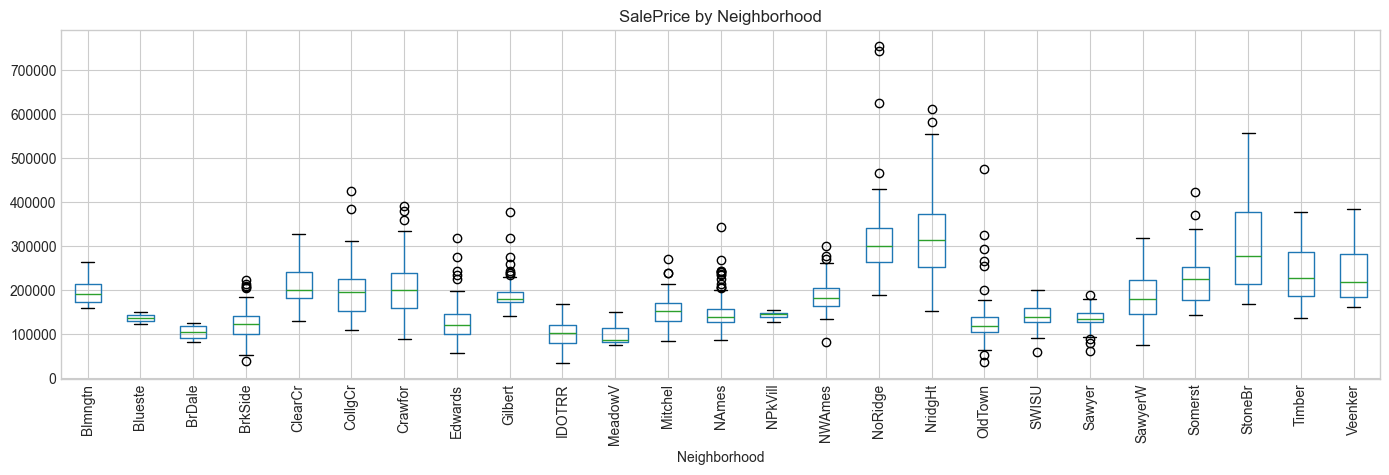

In [15]:
# Box plot: Neighborhood vs SalePrice
order = train.groupby('Neighborhood')['SalePrice'].median().sort_values().index
plt.figure(figsize=(14, 5))
train.boxplot(column='SalePrice', by='Neighborhood', ax=plt.gca())
plt.xticks(rotation=90)
plt.title('SalePrice by Neighborhood')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 4. Preprocessing

#### Remove Outliers

In [16]:
# Remove known outliers (large GrLivArea with very low price)
print(f'Train before removing outliers: {train.shape}')
print(f'Train before removing outliers: {train["GrLivArea"].shape}, {train["SalePrice"].shape}\n')
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 200000))].reset_index(drop=True)

print(f'Train after removing outliers: {train.shape}')
print(f'Train after removing outliers: {train["GrLivArea"].shape}, {train["SalePrice"].shape}')

Train before removing outliers: (1460, 81)
Train before removing outliers: (1460,), (1460,)

Train after removing outliers: (1458, 81)
Train after removing outliers: (1458,), (1458,)


### Separate Target & Combine Datasets

In [17]:
# Log-transform target
y_train = np.log1p(train['SalePrice'])

# Drop Id and SalePrice, then combine train+test for consistent preprocessing
train_ids = train['Id']
test_ids  = test['Id']

In [18]:
all_data = pd.concat([train.drop(['Id', 'SalePrice'], axis=1),
                    test.drop('Id', axis=1)], axis=0).reset_index(drop=True)

print(f'Combined data shape: {all_data.shape}')

Combined data shape: (2917, 79)


### Handle Missing Values

In [19]:
# Columns selected by this preprocessing step
cat_cols = all_data.select_dtypes(include='object').columns
num_cols = all_data.select_dtypes(include=[np.number]).columns

# Only columns that still have missing values
missing_before = all_data.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

cat_missing_cols = [col for col in cat_cols if col in missing_before.index]
num_missing_cols = [col for col in num_cols if col in missing_before.index]

print("Remaining categorical columns with missing values:")
print(cat_missing_cols)

print("\nRemaining numerical columns with missing values:")
print(num_missing_cols)

Remaining categorical columns with missing values:
['MSZoning', 'Alley', 'Utilities', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType']

Remaining numerical columns with missing values:
['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea']


In [20]:
summary = []

for col in cat_missing_cols:
    summary.append({
        "Column": col,
        "Type": "Categorical",
        "Missing Count": all_data[col].isnull().sum(),
        "Missing %": round(all_data[col].isnull().mean() * 100, 2),
        "Fill Method": "Mode",
        "Fill Value": all_data[col].mode()[0]
    })

for col in num_missing_cols:
    summary.append({
        "Column": col,
        "Type": "Numerical",
        "Missing Count": all_data[col].isnull().sum(),
        "Missing %": round(all_data[col].isnull().mean() * 100, 2),
        "Fill Method": "Median",
        "Fill Value": all_data[col].median()
    })

missing_summary = pd.DataFrame(summary)
display(missing_summary)

,Column,Type,Missing Count,Missing %,Fill Method,Fill Value
0,MSZoning,Categorical,4,0.14,Mode,RL
1,Alley,Categorical,2719,93.21,Mode,Grvl
2,Utilities,Categorical,2,0.07,Mode,AllPub
3,Exterior1st,Categorical,1,0.03,Mode,VinylSd
4,Exterior2nd,Categorical,1,0.03,Mode,VinylSd
5,MasVnrType,Categorical,1766,60.54,Mode,BrkFace
6,BsmtQual,Categorical,81,2.78,Mode,TA
7,BsmtCond,Categorical,82,2.81,Mode,TA
8,BsmtExposure,Categorical,82,2.81,Mode,No
9,BsmtFinType1,Categorical,79,2.71,Mode,Unf


In [21]:
all_data['MasVnrArea'].value_counts().sum()

2894

In [22]:
all_data['MasVnrArea'].value_counts()

MasVnrArea
0.0      1738
120.0      15
176.0      13
200.0      13
216.0      12
         ... 
137.0       1
274.0       1
415.0       1
760.0       1
382.0       1
Name: count, Length: 442, dtype: int64

In [23]:
all_data['MasVnrArea'].sort_values().median()

0.0

In [24]:
# drop columns with >40% missing values
cols_to_drop = missing_summary[missing_summary['Missing %'] > 40]['Column'].tolist()
all_data = all_data.drop(columns=cols_to_drop)

In [25]:
summary = []

for col in [col for col in cat_missing_cols if col in all_data.columns]:
    summary.append({
        "Column": col,
        "Type": "Categorical",
        "Missing Count": all_data[col].isnull().sum(),
        "Missing %": round(all_data[col].isnull().mean() * 100, 2),
        "Fill Method": "Mode",
        "Fill Value": all_data[col].mode()[0]
    })

for col in [col for col in num_missing_cols if col in all_data.columns]:
    summary.append({
        "Column": col,
        "Type": "Numerical",
        "Missing Count": all_data[col].isnull().sum(),
        "Missing %": round(all_data[col].isnull().mean() * 100, 2),
        "Fill Method": "Median",
        "Fill Value": all_data[col].median()
    })

missing_summary = pd.DataFrame(summary)
display(missing_summary)

,Column,Type,Missing Count,Missing %,Fill Method,Fill Value
0,MSZoning,Categorical,4,0.14,Mode,RL
1,Utilities,Categorical,2,0.07,Mode,AllPub
2,Exterior1st,Categorical,1,0.03,Mode,VinylSd
3,Exterior2nd,Categorical,1,0.03,Mode,VinylSd
4,BsmtQual,Categorical,81,2.78,Mode,TA
5,BsmtCond,Categorical,82,2.81,Mode,TA
6,BsmtExposure,Categorical,82,2.81,Mode,No
7,BsmtFinType1,Categorical,79,2.71,Mode,Unf
8,BsmtFinType2,Categorical,80,2.74,Mode,Unf
9,Electrical,Categorical,1,0.03,Mode,SBrkr


In [26]:
# LotFrontage: fill with median per Neighborhood
# street frontage depends on location
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [27]:
print(f'missing Values: {all_data.isnull().sum().sum()}')

missing Values: 1243


In [28]:
# Remaining categoricals: fill with mode
cat_cols = all_data.select_dtypes(include='object').columns
all_data[cat_cols] = all_data[cat_cols].fillna(all_data[cat_cols].mode().iloc[0])

In [29]:
# Remaining numericals: fill with median
num_cols = all_data.select_dtypes(include=[np.number]).columns
all_data[num_cols] = all_data[num_cols].fillna(all_data[num_cols].median())

In [30]:
print(f'Remaining missing: {all_data.isnull().sum().sum()}')

Remaining missing: 0


In [31]:
all_data.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPor

#### Feature Engineering

In [32]:
# New features that capture important combined information
all_data['TotalSF']       = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBath']     = all_data['FullBath'] + 0.5 * all_data['HalfBath']
all_data['TotalPorchSF']  = all_data['OpenPorchSF'] + all_data['EnclosedPorch'] + all_data['3SsnPorch'] + all_data['ScreenPorch']
all_data['HouseAge']      = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge']      = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['IsRemodeled']   = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)

print('New features added:', ['TotalSF', 'TotalBath', 'TotalPorchSF', 'HouseAge', 'RemodAge', 'IsRemodeled'])

New features added: ['TotalSF', 'TotalBath', 'TotalPorchSF', 'HouseAge', 'RemodAge', 'IsRemodeled']


In [33]:
# Drop old columns used to create new engineered features
drop_cols = [
    # used in TotalSF
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',

    # used in TotalBath
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',

    # used in TotalPorchSF
    'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',

    # used in age/remodel features
    'YearBuilt', 'YearRemodAdd'

    ,'MasVnrArea' , 'BsmtFinSF2'
]

all_data = all_data.drop(columns=drop_cols, errors='ignore')

In [34]:
all_data.shape

(2917, 64)

#### Encode Categorical Features

In [35]:
# Ordinal encoding for quality/condition columns (meaningful order)
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual',
                'GarageQual', 'GarageCond']

all_data[ordinal_cols] = all_data[ordinal_cols].replace(quality_map)

In [36]:
all_data.shape

(2917, 64)

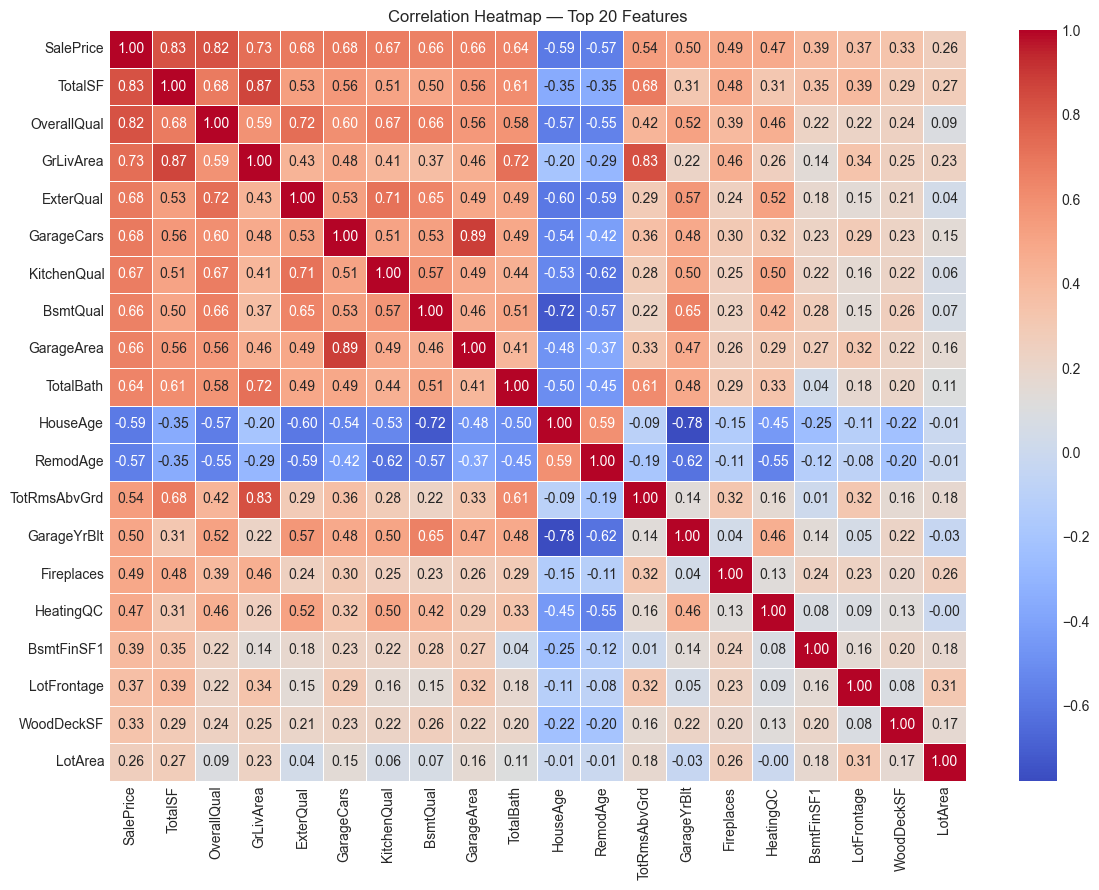

In [37]:
# Correlation matrix on preprocessed (one-hot encoded) data vs log-target

plt.figure(figsize=(12, 9))

proc_train = all_data.iloc[:len(train)].copy() # X

proc_train['SalePrice'] = y_train.values # log(SalePrice) as target

num_proc = proc_train.select_dtypes(include=[np.number])

top_proc = num_proc.corr()['SalePrice'].abs().sort_values(ascending=False).head(20).index.tolist()


sns.heatmap(proc_train[top_proc].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Top 20 Features')
plt.tight_layout()
plt.show()

In [38]:
# One-hot encode all remaining categorical columns
all_data = pd.get_dummies(all_data)

print(f'Shape after one-hot encoding: {all_data.shape}')

Shape after one-hot encoding: (2917, 228)


#### Split Back & Scale

In [39]:
# Split back into train and test
X_train = all_data.iloc[:len(train)].values
X_test  = all_data.iloc[len(train):].values

print(f'X_train: {X_train.shape}   |   X_test: {X_test.shape}   |   y_train: {y_train.shape}')

X_train: (1458, 228)   |   X_test: (1459, 228)   |   y_train: (1458,)


In [40]:
# Scale features
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## 5. Modeling && Evaluation with Cross Validation - training Data

### baseline_model - SVM

In [41]:
# SVR with RBF kernel
svr = SVR(kernel='rbf')

In [42]:
svr.fit(X_train, y_train)

SVR()

In [43]:
y_train_pred = svr.predict(X_train)

In [44]:
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_train_pred)

print(f'Mean Squared Error on training data: {mse}')
print(f'Root Mean Squared Error on training data: {rmse}')
print(f"R2 Score: {r2}")

Mean Squared Error on training data: 0.005905962253041452
Root Mean Squared Error on training data: 0.07685025864004266
R2 Score: 0.963009307025486


In [45]:
# 5-Fold CV using RMSLE (standard Kaggle metric for this competition)
cv_scores = cross_val_score(svr, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_rmsle  = -cv_scores

print(f'CV RMSLE scores : {cv_rmsle.round(4)}')
print(f'Mean  RMSLE     : {cv_rmsle.mean():.4f}')
print(f'Std   RMSLE     : {cv_rmsle.std():.4f}')

CV RMSLE scores : [0.1735 0.2007 0.2116 0.1633 0.1869]
Mean  RMSLE     : 0.1872
Std   RMSLE     : 0.0175


In [46]:
# Training RMSLE (sanity check)
train_rmsle = np.sqrt(mean_squared_error(y_train, y_train_pred))

print(f'Training RMSLE : {train_rmsle:.4f}')
print(f'CV Mean  RMSLE : {cv_rmsle.mean():.4f}')

Training RMSLE : 0.0769
CV Mean  RMSLE : 0.1872


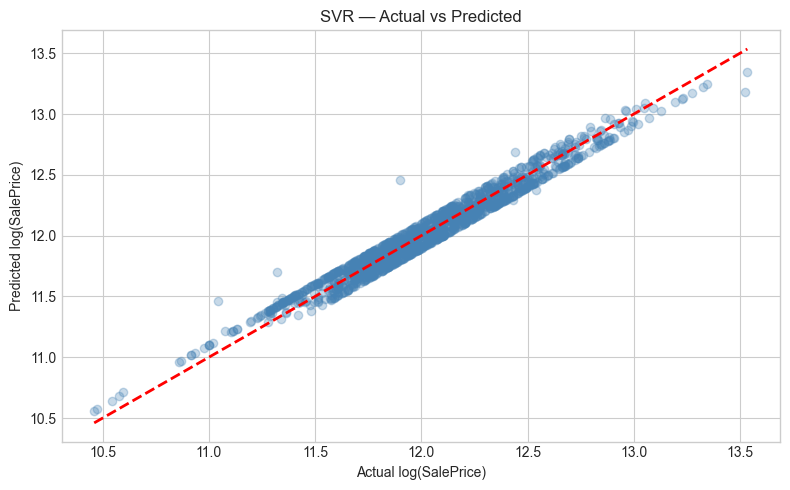

In [47]:
# Actual vs Predicted (on training set)
plt.figure(figsize=(8, 5))
plt.scatter(y_train, y_train_pred, alpha=0.3, color='steelblue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual log(SalePrice)')
plt.ylabel('Predicted log(SalePrice)')
plt.title('SVR — Actual vs Predicted')
plt.tight_layout()
plt.show()

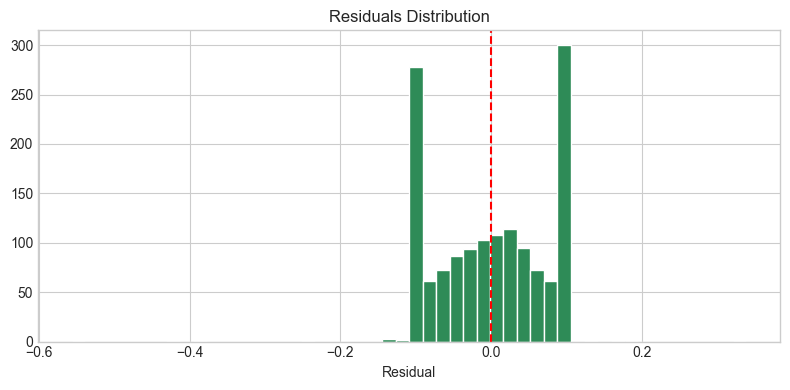

In [48]:
# Residuals distribution
residuals = np.asarray(y_train) - y_train_pred

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, color='seagreen', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual')
plt.title('Residuals Distribution')
plt.tight_layout()
plt.show()

### Tuned SVM

In [49]:
param_grid = {'C': [10, 100, 1000], 'gamma': [0.0001, 0.001, 0.01], 'epsilon': [0.001, 0.01, 0.1]}
grid = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)
print(grid.best_params_, -grid.best_score_)

{'C': 10, 'epsilon': 0.01, 'gamma': 0.0001} 0.11537705291806193


In [50]:
# SVR with RBF kernel
svr_exp1 = SVR(kernel='rbf', C=10, epsilon=0.01, gamma=0.0001)

In [51]:
svr_exp1.fit(X_train, y_train)

SVR(C=10, epsilon=0.01, gamma=0.0001)

In [52]:
y_train_pred_exp1 = svr_exp1.predict(X_train)

mse = mean_squared_error(y_train, y_train_pred_exp1)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_train_pred_exp1)

print(f'Mean Squared Error on training data: {mse}')
print(f'Root Mean Squared Error on training data: {rmse}')
print(f"R2 Score: {r2}")

Mean Squared Error on training data: 0.008223292666191638
Root Mean Squared Error on training data: 0.09068237241157533
R2 Score: 0.9484952186922601


In [53]:
y_train_pred_exp1 = svr_exp1.predict(X_train)

mse = mean_squared_error(y_train, y_train_pred_exp1)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_train_pred_exp1)

print(f'Mean Squared Error on training data: {mse}')
print(f'Root Mean Squared Error on training data: {rmse}')
print(f"R2 Score: {r2}")

Mean Squared Error on training data: 0.008223292666191638
Root Mean Squared Error on training data: 0.09068237241157533
R2 Score: 0.9484952186922601


In [54]:
# 5-Fold CV using RMSLE (standard Kaggle metric for this competition)
cv_scores_exp1 = cross_val_score(svr_exp1, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_rmsle_exp1  = -cv_scores_exp1

print(f'CV RMSLE scores : {cv_rmsle_exp1.round(4)}')
print(f'Mean  RMSLE     : {cv_rmsle_exp1.mean():.4f}')
print(f'Std   RMSLE     : {cv_rmsle_exp1.std():.4f}')

CV RMSLE scores : [0.1082 0.1253 0.1202 0.1081 0.1151]
Mean  RMSLE     : 0.1154
Std   RMSLE     : 0.0067


In [55]:
# Training RMSLE (sanity check)
train_rmsle_exp1 = np.sqrt(mean_squared_error(y_train, y_train_pred_exp1))

print(f'Training RMSLE : {train_rmsle_exp1:.4f}')
print(f'CV Mean  RMSLE : {cv_rmsle_exp1.mean():.4f}')

Training RMSLE : 0.0907
CV Mean  RMSLE : 0.1154


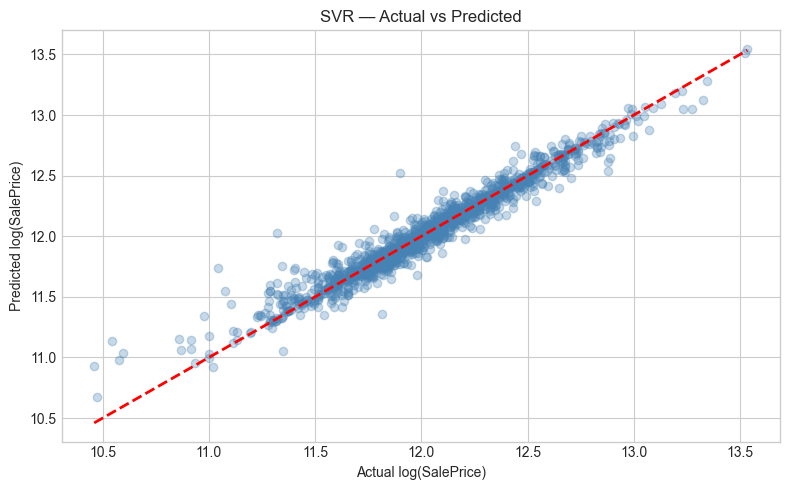

In [56]:
# Actual vs Predicted (on training set)
plt.figure(figsize=(8, 5))
plt.scatter(y_train, y_train_pred_exp1, alpha=0.3, color='steelblue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual log(SalePrice)')
plt.ylabel('Predicted log(SalePrice)')
plt.title('SVR — Actual vs Predicted')
plt.tight_layout()
plt.show()

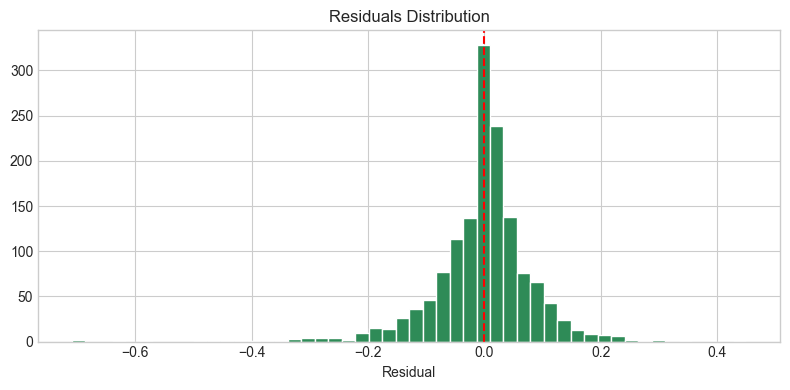

In [57]:
# Residuals distribution
residuals = np.asarray(y_train) - y_train_pred_exp1

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, color='seagreen', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual')
plt.title('Residuals Distribution')
plt.tight_layout()
plt.show()

### Linear Regression

In [58]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [59]:
lr_train_pred = lr.predict(X_train)

lr_mse = mean_squared_error(y_train, lr_train_pred)
lr_rmsle = np.sqrt(lr_mse)
lr_r2 = r2_score(y_train, lr_train_pred)

print(f'Mean Squared Error on training data: {lr_mse}')
print(f'Root Mean Squared Error on training data: {lr_rmsle}')
print(f"R2 Score: {lr_r2}")

Mean Squared Error on training data: 0.008900243231044075
Root Mean Squared Error on training data: 0.0943411004337138
R2 Score: 0.9442552880204234


In [60]:
# 5-Fold CV using RMSLE (standard Kaggle metric for this competition)
lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
lr_cv_rmsle  = -lr_cv_scores

print(f'CV RMSLE scores : {lr_cv_rmsle.round(4)}')
print(f'Mean  RMSLE     : {lr_cv_rmsle.mean():.4f}')
print(f'Std   RMSLE     : {lr_cv_rmsle.std():.4f}')

CV RMSLE scores : [2.38954293e+12 4.54110758e+11 8.92742711e+11 2.46455763e+12
 6.73328737e+11]
Mean  RMSLE     : 1374856553216.8286
Std   RMSLE     : 870561282526.8547


In [61]:
# Training RMSLE (sanity check)
print(f'Training RMSLE : {lr_rmsle:.4f}')
print(f'CV Mean  RMSLE : {lr_cv_rmsle.mean():.4f}')

Training RMSLE : 0.0943
CV Mean  RMSLE : 1374856553216.8286


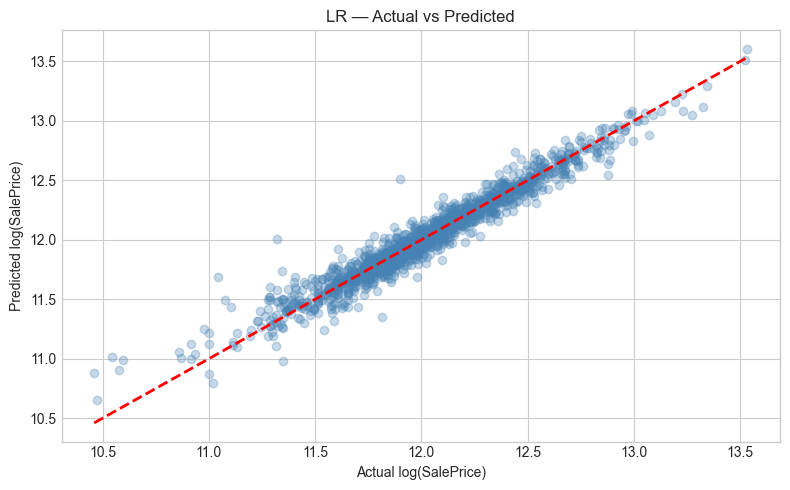

In [62]:
# Actual vs Predicted (on training set)
plt.figure(figsize=(8, 5))
plt.scatter(y_train, lr_train_pred, alpha=0.3, color='steelblue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual log(SalePrice)')
plt.ylabel('Predicted log(SalePrice)')
plt.title('LR — Actual vs Predicted')
plt.tight_layout()
plt.show()

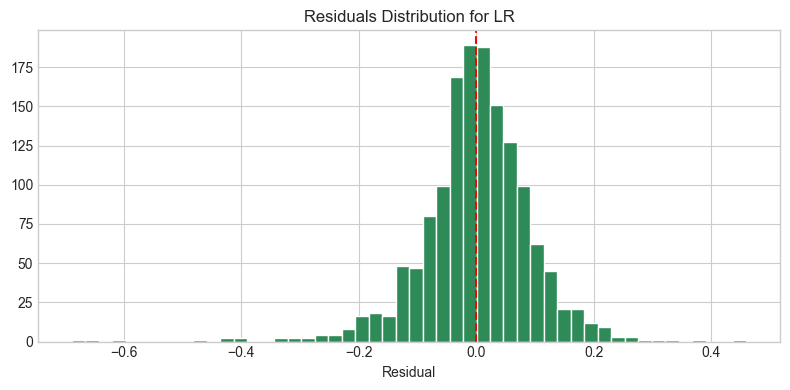

In [63]:
# Residuals distribution
residuals = np.asarray(y_train) - lr_train_pred

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, color='seagreen', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual')
plt.title('Residuals Distribution for LR')
plt.tight_layout()
plt.show()

### Lasso

In [64]:
param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1]}
grid = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)
print(grid.best_params_, -grid.best_score_)

{'alpha': 0.001} 0.11565226498524905


In [65]:
lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)

Lasso(alpha=0.001)

In [66]:
lasso_train_pred = lasso.predict(X_train)

lasso_mse = mean_squared_error(y_train, lasso_train_pred)
lasso_rmsle = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_train, lasso_train_pred)

print(f'Mean Squared Error on training data: {lasso_mse}')
print(f'Root Mean Squared Error on training data: {lasso_rmsle}')
print(f"R2 Score: {lasso_r2}")

Mean Squared Error on training data: 0.009183018689800695
Root Mean Squared Error on training data: 0.09582806838187179
R2 Score: 0.9424841862545414


In [67]:
# 5-Fold CV using RMSLE (standard Kaggle metric for this competition)
lasso_cv_scores = cross_val_score(lasso, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
lasso_cv_rmsle  = -lasso_cv_scores

print(f'CV RMSLE scores : {lasso_cv_rmsle.round(4)}')
print(f'Mean  RMSLE     : {lasso_cv_rmsle.mean():.4f}')
print(f'Std   RMSLE     : {lasso_cv_rmsle.std():.4f}')

CV RMSLE scores : [0.1088 0.1227 0.1251 0.1078 0.1138]
Mean  RMSLE     : 0.1157
Std   RMSLE     : 0.0071


In [68]:
# Training RMSLE (sanity check)
print(f'Training RMSLE : {lasso_rmsle:.4f}')
print(f'CV Mean  RMSLE : {lasso_cv_rmsle.mean():.4f}')

Training RMSLE : 0.0958
CV Mean  RMSLE : 0.1157


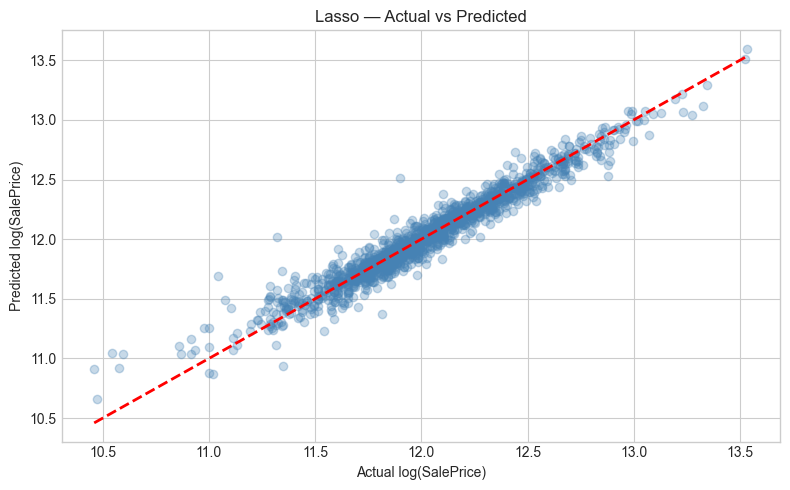

In [69]:
# Actual vs Predicted (on training set)
plt.figure(figsize=(8, 5))
plt.scatter(y_train, lasso_train_pred, alpha=0.3, color='steelblue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual log(SalePrice)')
plt.ylabel('Predicted log(SalePrice)')
plt.title('Lasso — Actual vs Predicted')
plt.tight_layout()
plt.show()

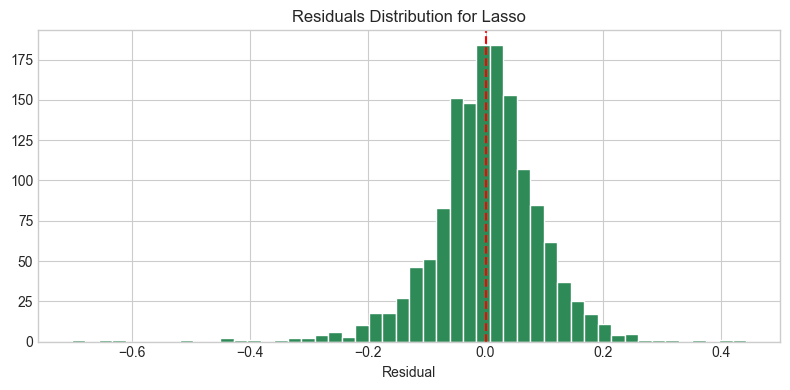

In [70]:
# Residuals distribution
residuals = np.asarray(y_train) - lasso_train_pred

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, color='seagreen', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual')
plt.title('Residuals Distribution for Lasso')
plt.tight_layout()
plt.show()

### XGBoost

In [ ]:
param_grid = {
    "n_estimators": [500, 1000, 1500],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.05, 0.1],
    "reg_alpha": [0, 0.001, 0.01],
    "reg_lambda": [1, 3, 5]
}

grid = GridSearchCV(XGBRegressor(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)
print(grid.best_params_, -grid.best_score_)

In [166]:
xgb = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.5,
    gamma=0.05,
    reg_alpha=0.01,
    reg_lambda=1,
    min_child_weight=3,
    random_state=42,
)

In [167]:
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.05, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [168]:
xgb_train_pred = xgb.predict(X_train)

xgb_mse = mean_squared_error(y_train, xgb_train_pred)
xgb_rmsle = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_train, xgb_train_pred)

print(f'Mean Squared Error on training data: {xgb_mse}')
print(f'Root Mean Squared Error on training data: {xgb_rmsle}')
print(f"R2 Score: {xgb_r2}")

Mean Squared Error on training data: 0.006497482380155875
Root Mean Squared Error on training data: 0.08060696235534419
R2 Score: 0.9593044510726619


In [169]:
# 5-Fold CV using RMSLE (standard Kaggle metric for this competition)
xgb_cv_scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
xgb_cv_rmsle  = -xgb_cv_scores

print(f'CV RMSLE scores : {xgb_cv_rmsle.round(4)}')
print(f'Mean  RMSLE     : {xgb_cv_rmsle.mean():.4f}')
print(f'Std   RMSLE     : {xgb_cv_rmsle.std():.4f}')

CV RMSLE scores : [0.1082 0.1201 0.1232 0.1016 0.1157]
Mean  RMSLE     : 0.1138
Std   RMSLE     : 0.0079


In [170]:
# Training RMSLE (sanity check)
print(f'Training RMSLE : {xgb_rmsle:.4f}')
print(f'CV Mean  RMSLE : {xgb_cv_rmsle.mean():.4f}')

Training RMSLE : 0.0806
CV Mean  RMSLE : 0.1138


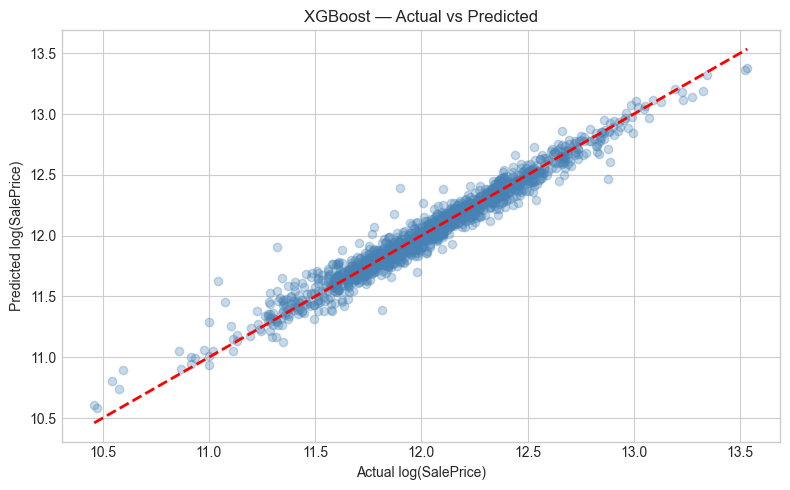

In [171]:
# Actual vs Predicted (on training set)
plt.figure(figsize=(8, 5))
plt.scatter(y_train, xgb_train_pred, alpha=0.3, color='steelblue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual log(SalePrice)')
plt.ylabel('Predicted log(SalePrice)')
plt.title('XGBoost — Actual vs Predicted')
plt.tight_layout()
plt.show()

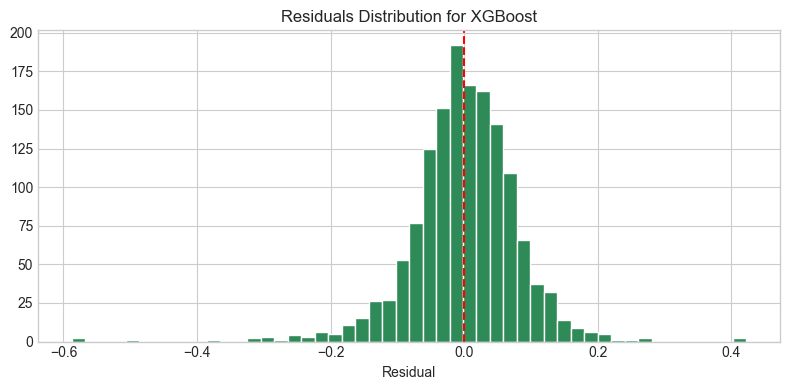

In [172]:
# Residuals distribution
residuals = np.asarray(y_train) - xgb_train_pred

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, color='seagreen', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual')
plt.title('Residuals Distribution for XGBoost')
plt.tight_layout()
plt.show()

### 📊 Final Comparison — All Models

In [173]:
pd.set_option('display.float_format', '{:.4f}'.format)

results = {
    'SVR (baseline)': {
        'Train RMSLE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'CV RMSLE': cv_rmsle.mean(),
        'CV Std': cv_rmsle.std()
    },
    'SVR (tuned)': {
        'Train RMSLE': train_rmsle_exp1,
        'CV RMSLE': cv_rmsle_exp1.mean(),
        'CV Std': cv_rmsle_exp1.std()
    },
    'Linear Reg': {
        'Train RMSLE': lr_rmsle,
        'CV RMSLE': lr_cv_rmsle.mean(),
        'CV Std': lr_cv_rmsle.std()
    },
    'Lasso': {
        'Train RMSLE': lasso_rmsle,
        'CV RMSLE': lasso_cv_rmsle.mean(),
        'CV Std': lasso_cv_rmsle.std()
    },
    'XGBoost': {
        'Train RMSLE': xgb_rmsle,
        'CV RMSLE': xgb_cv_rmsle.mean(),
        'CV Std': xgb_cv_rmsle.std()
    },
}

df_results = pd.DataFrame(results).T

df_results['Overfit Gap'] = (
    df_results['Train RMSLE'] - df_results['CV RMSLE']
).abs()

df_results = df_results.round(4)

df_results = df_results.sort_values('CV RMSLE')

df_results

,Train RMSLE,CV RMSLE,CV Std,Overfit Gap
XGBoost,0.0806,0.1138,0.0079,0.0332
SVR (tuned),0.0907,0.1154,0.0067,0.0247
Lasso,0.0958,0.1157,0.0071,0.0198
SVR (baseline),0.0769,0.1872,0.0175,0.1103
Linear Reg,0.0943,1374856553216.8286,870561282526.8547,1374856553216.7344


### 💾 Submissions

In [ ]:
# pd.DataFrame({'Id': test_ids, 'SalePrice': np.expm1(svr_exp1.predict(X_test))}).to_csv('submission_svr_tuned.csv', index=False)
# print('submission_svr_tuned.csv saved')

submission_svr_tuned.csv saved


In [ ]:
# pd.DataFrame({'Id': test_ids, 'SalePrice': np.expm1(lasso.predict(X_test))}).to_csv('submission_lasso.csv', index=False)
# print('submission_lasso.csv saved')

submission_lasso.csv saved


In [ ]:
# pd.DataFrame({'Id': test_ids, 'SalePrice': np.expm1(xgb.predict(X_test))}).to_csv('submission_xgboost.csv', index=False)
# print('submission_xgboost.csv saved')

submission_xgboost.csv saved
